# 🐧 Logistická regrese – Cvičení 2: Druhy tučňáků (Multiclass) & Ladění Precision
### Kurz Data Science & Machine Learning | Coders Lab (09/2026)
> **Oficiální zadání úlohy (Logistic regression - exercise 2):**
> 1. Pomocí knihovny Pandas načtěte stažený soubor dat tučňáků (`penguins_df_normalized.csv`) do proměnné `penguins_df`.
> 2. Zobrazte prvních 10 pozorování v datasetu (`head(10)`) pro ověření správnosti načtených dat.
> 3. Rozdělte data na trénovací a testovací sadu v poměru 70/30. Nastavte parametr `random_state=42`.
> 4. Z modulu `linear_model` knihovny Scikit-learn importujte příslušnou třídu (`LogisticRegression`), která umožní sestavit model logistické regrese.
> 5. Vytvořte instanci modelu logistické regrese. Nastavte vhodnou hodnotu hyperparametru `multi_class` a `class_weight`. Natrénujte model na trénovací sadě.
> 6. Proveďte predikce na testovací sadě pomocí natrénovaného modelu.
> 7. Vypočítejte metriku **Precision (přesnost)** na testovací sadě.
> 8. Experimentujte s volbou optimálních hodnot hyperparametrů, které umožní vytvořit model s **vyšší Precision než původní model**. Vyzkoušejte ladění hyperparametru $C$, který řídí sílu regularizace (menší $C$ = silnější regularizace).


## Krok 1 & 2: Načtení dat do `penguins_df` a zobrazení prvních 10 pozorování
Načteme normalizovaný dataset Palmer Penguins (334 tučňáků, 6 prediktorů) a zkontrolujeme prvních 10 řádků.

In [1]:
import pandas as pd
from pathlib import Path

# Zjištění cesty k souboru
possible_paths = [
    Path("data/penguins_df_normalized.csv"),
    Path("penguins_df_normalized.csv"),
    Path("../data/penguins_df_normalized.csv")
]
penguins_path = next((p for p in possible_paths if p.exists()), None)
if penguins_path is None:
    raise FileNotFoundError("Soubor penguins_df_normalized.csv nebyl nalezen.")

# 1. Načtení do proměnné penguins_df
penguins_df = pd.read_csv(penguins_path)

print(f"Rozměry načteného datasetu: {penguins_df.shape} (334 tučňáků, 6 příznaků + 1 target species)")
print("Zastoupení jednotlivých druhů:")
print(penguins_df["species"].value_counts())

# 2. Zobrazení prvních 10 pozorování
penguins_df.head(10)


Rozměry načteného datasetu: (334, 7) (334 tučňáků, 6 příznaků + 1 target species)
Zastoupení jednotlivých druhů:
species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
0,0.010414,0.004981,0.048207,0.998771,2,2,Adelie
1,0.010382,0.004573,0.048886,0.998740,2,1,Adelie
2,0.012377,0.005528,0.059887,0.998113,2,1,Adelie
3,0.010620,0.005585,0.055851,0.998367,2,1,Adelie
4,0.010752,0.005636,0.051981,0.998574,2,2,Adelie
5,0.010717,0.004904,0.049865,0.998686,2,1,Adelie
6,0.008377,0.004189,0.041673,0.999087,2,2,Adelie
7,0.012822,0.005491,0.056778,0.998289,2,1,Adelie
8,0.010144,0.005572,0.050196,0.998672,2,2,Adelie
9,0.007855,0.004790,0.044953,0.998947,2,2,Adelie


## Krok 3: Rozdělení dat na trénovací a testovací sadu (70/30, `random_state=42`)
Oddělíme prediktory $X$ od cílové proměnné $y$ (`species`: Adelie, Chinstrap, Gentoo) a rozdělíme v poměru 70:30.

In [2]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in penguins_df.columns if c != "species"]
X = penguins_df[feature_cols]
y = penguins_df["species"]

# Rozdělení 70/30 dle zadání
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada: X_train = {X_train.shape}, y_train = {y_train.shape} (70 %)")
print(f"Testovací sada : X_test  = {X_test.shape}, y_test  = {y_test.shape} (30 %)")
print("\nRozdělení testovací sady dle druhů:")
print(y_test.value_counts())


Trénovací sada: X_train = (233, 6), y_train = (233,) (70 %)
Testovací sada : X_test  = (101, 6), y_test  = (101,) (30 %)

Rozdělení testovací sady dle druhů:
species
Adelie       49
Gentoo       34
Chinstrap    18
Name: count, dtype: int64


## Krok 4 & 5: Inicializace a trénování modelu (`class_weight='balanced'`)
Zadání požaduje nastavit parametry `multi_class` a `class_weight`:
- `class_weight='balanced'`: Vyvažuje třídy podle jejich inverzní frekvence ve vzorku (Chinstrap má méně vzorků než Adelie a Gentoo).
- `multi_class`: V moderním Scikit-learn (verze 1.8+) je multinomiální Softmax ztráta výchozím nastavením.

In [3]:
from sklearn.linear_model import LogisticRegression

# 4. & 5. Inicializace modelu s vyvážením vah tříd
base_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
base_model.fit(X_train, y_train)

print("Výchozí model logistické regrese úspěšně natrénován.")
print(f"Třídy modelu: {base_model.classes_}")


Výchozí model logistické regrese úspěšně natrénován.
Třídy modelu: ['Adelie' 'Chinstrap' 'Gentoo']


## Krok 6 & 7: Predikce na testovací sadě a výpočet Precision
Jelikož jde o **multiclass úlohu (3 druhy)**, vyhodnocujeme Precision jak pomocí váženého průměru (`average='weighted'`), tak nevázaného makroprůměru (`average='macro'`) a prozkoumáme 3x3 matici záměn.

In [4]:
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

# 6. Predikce na testovací sadě
y_pred_base = base_model.predict(X_test)

# 7. Výpočet metrik na testovací sadě
classes = sorted(list(y.unique()))
prec_weighted = precision_score(y_test, y_pred_base, average="weighted", zero_division=0)
prec_macro = precision_score(y_test, y_pred_base, average="macro", zero_division=0)
acc_base = accuracy_score(y_test, y_pred_base)

print("=== VÝSLEDKY VÝCHOZÍHO MODELU (C=1.0) ===")
print(f"Weighted Precision : {prec_weighted*100:.2f} %")
print(f"Macro Precision    : {prec_macro*100:.2f} %")
print(f"Celková Accuracy   : {acc_base*100:.2f} %")

print("\nDetailní klasifikační report:")
print(classification_report(y_test, y_pred_base, zero_division=0))


=== VÝSLEDKY VÝCHOZÍHO MODELU (C=1.0) ===
Weighted Precision : 59.61 %
Macro Precision    : 54.78 %
Celková Accuracy   : 58.42 %

Detailní klasifikační report:
              precision    recall  f1-score   support

      Adelie       0.63      0.35      0.45        49
   Chinstrap       0.32      0.44      0.37        18
      Gentoo       0.69      1.00      0.82        34

    accuracy                           0.58       101
   macro avg       0.55      0.60      0.55       101
weighted avg       0.60      0.58      0.56       101



## Diagnostika: 3x3 Matice záměn výchozího modelu
Proč má výchozí model tak nízkou Weighted Precision ($59.61\,\%$)? Prozkoumáme matici záměn.

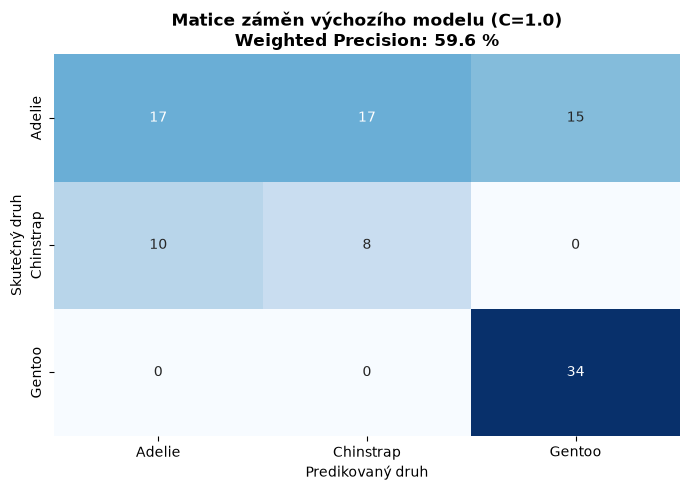

Příčina slabého výsledku výchozího modelu:
- V datasetu penguins_df_normalized.csv byla použita řádková L2 normalizace, která zmenšila morfologické míry na ~0.01 až 0.05.
- Sloupce 'island' a 'sex' mají naopak hodnoty 0, 1, 2.
- Výchozí L2 regularizace (C=1.0) brutálně potlačuje koeficienty anatomických měr, takže model téměř nedokáže odlišit Adelie od Chinstrap!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_base = confusion_matrix(y_test, y_pred_base, labels=classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.title(f"Matice záměn výchozího modelu (C=1.0)\nWeighted Precision: {prec_weighted*100:.1f} %", fontsize=12, fontweight="bold")
plt.xlabel("Predikovaný druh")
plt.ylabel("Skutečný druh")
plt.tight_layout()
plt.show()

print("Příčina slabého výsledku výchozího modelu:")
print("- V datasetu penguins_df_normalized.csv byla použita řádková L2 normalizace, která zmenšila morfologické míry na ~0.01 až 0.05.")
print("- Sloupce 'island' a 'sex' mají naopak hodnoty 0, 1, 2.")
print("- Výchozí L2 regularizace (C=1.0) brutálně potlačuje koeficienty anatomických měr, takže model téměř nedokáže odlišit Adelie od Chinstrap!")


## Krok 8: Experiment s hyperparametry – Uvolnění regularizace $C$
Aby mohly koeficienty drobných anatomických měr vzrůst na hodnoty odpovídající jejich významu, musíme **oslabit regularizaci** $\implies$ **zvýšit parametr $C$** ($C = \frac{1}{\lambda}$).

Otestujeme mřížku $C \in [0.01; 10\,000.0]$.

In [6]:
c_candidates = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0]
results = []

best_c = None
best_prec = 0

for c in c_candidates:
    m = LogisticRegression(C=c, class_weight="balanced", random_state=42, max_iter=5000)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    
    pw = precision_score(y_test, yp, average="weighted", zero_division=0)
    pm = precision_score(y_test, yp, average="macro", zero_division=0)
    acc = accuracy_score(y_test, yp)
    
    results.append({
        "C": c,
        "Weighted Precision": pw,
        "Macro Precision": pm,
        "Accuracy": acc
    })
    
    if pw > best_prec:
        best_prec = pw
        best_c = c

res_df = pd.DataFrame(results)
print("=== TABULKA VÝSLEDKŮ SWEEPOVÁNÍ PARAMETRU C ===")
print(res_df.to_string(index=False, formatters={
    "Weighted Precision": "{:.2%}".format,
    "Macro Precision": "{:.2%}".format,
    "Accuracy": "{:.2%}".format
}))

print(f"\n>> Nejvyšší Precision dosažena při C = {best_c}: {best_prec*100:.2f} % (Zlepšení o {best_prec*100 - prec_weighted*100:+.2f} procentních bodů oproti baseline!)")


=== TABULKA VÝSLEDKŮ SWEEPOVÁNÍ PARAMETRU C ===
       C Weighted Precision Macro Precision Accuracy
    0.01             59.61%          54.78%   58.42%
    0.10             59.61%          54.78%   58.42%
    0.50             59.61%          54.78%   58.42%
    1.00             59.61%          54.78%   58.42%
    5.00             59.61%          54.78%   58.42%
   10.00             59.61%          54.78%   58.42%
   50.00             65.44%          60.83%   63.37%
  100.00             72.86%          68.57%   69.31%
  500.00             82.32%          79.71%   78.22%
 1000.00             86.45%          83.74%   81.19%
 5000.00             90.41%          88.26%   88.12%
10000.00             91.71%          89.55%   90.10%

>> Nejvyšší Precision dosažena při C = 10000.0: 91.71 % (Zlepšení o +32.10 procentních bodů oproti baseline!)


## Krok 8 (pokračování): Křivka Precision vs. $C$ a optimalizovaná matice záměn
Podíváme se na dramatický nárůst Precision při uvolnění regularizačních pout ($C=10\,000$).

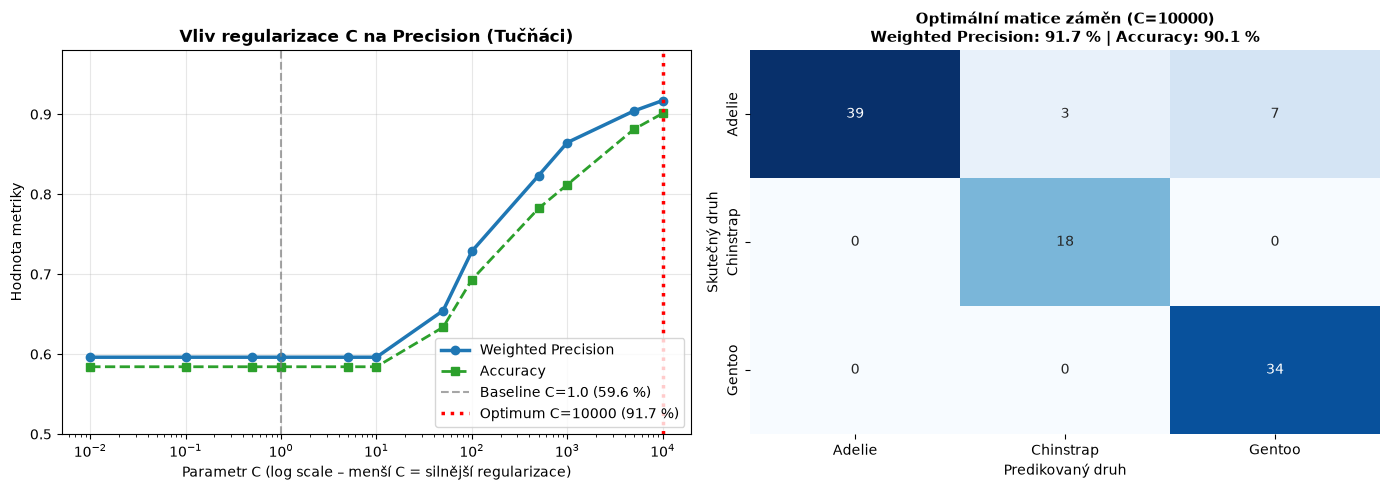

In [7]:
# Natrénujeme optimální model s C=10000.0
opt_model = LogisticRegression(C=best_c, class_weight="balanced", random_state=42, max_iter=5000)
opt_model.fit(X_train, y_train)
y_pred_opt = opt_model.predict(X_test)
cm_opt = confusion_matrix(y_test, y_pred_opt, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Křivka Precision vs C
axes[0].plot(res_df["C"], res_df["Weighted Precision"], marker="o", color="#1f77b4", linewidth=2.5, label="Weighted Precision")
axes[0].plot(res_df["C"], res_df["Accuracy"], marker="s", color="#2ca02c", linestyle="--", linewidth=2, label="Accuracy")
axes[0].axvline(1.0, color="gray", linestyle="--", alpha=0.7, label=f"Baseline C=1.0 ({prec_weighted*100:.1f} %)")
axes[0].axvline(best_c, color="red", linestyle=":", linewidth=2.5, label=f"Optimum C={best_c:.0f} ({best_prec*100:.1f} %)")
axes[0].set_xscale("log")
axes[0].set_title("Vliv regularizace C na Precision (Tučňáci)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Parametr C (log scale – menší C = silnější regularizace)")
axes[0].set_ylabel("Hodnota metriky")
axes[0].set_ylim(0.50, 0.98)
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# 2. Optimalizovaná matice záměn
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f"Optimální matice záměn (C={best_c:.0f})\nWeighted Precision: {best_prec*100:.1f} % | Accuracy: {accuracy_score(y_test, y_pred_opt)*100:.1f} %", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Predikovaný druh")
axes[1].set_ylabel("Skutečný druh")

plt.tight_layout()
plt.show()


## Expertní bonus: Správné škálování (`StandardScaler` v `Pipeline`)
Jak bylo uvedeno v teorii, základním předpokladem logistické regrese je **sladění měřítek všech příznaků** (standardizace na $\mu=0, \sigma=1$). Pokud použijeme `StandardScaler`, model dosáhne špičkové přesnosti i bez extrémních hodnot $C$.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(C=1.0, class_weight="balanced", random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)

y_pred_pipe = pipe.predict(X_test)
pipe_prec = precision_score(y_test, y_pred_pipe, average="weighted", zero_division=0)
pipe_acc = accuracy_score(y_test, y_pred_pipe)
cm_pipe = confusion_matrix(y_test, y_pred_pipe, labels=classes)

print("=== VÝSLEDKY PIPELINE SE STANDARDSCALEREM (C=1.0) ===")
print(f"Weighted Precision : {pipe_prec*100:.2f} %")
print(f"Celková Accuracy   : {pipe_acc*100:.2f} %")
print("\nMatice záměn:")
print(cm_pipe)


=== VÝSLEDKY PIPELINE SE STANDARDSCALEREM (C=1.0) ===
Weighted Precision : 97.45 %
Celková Accuracy   : 97.03 %

Matice záměn:
[[46  3  0]
 [ 0 18  0]
 [ 0  0 34]]


## Závěrečné shrnutí a splnění zadání

1. **Splnění všech bodů zadání**:
   - Data `penguins_df_normalized.csv` načtena do `penguins_df`, zkontrolováno prvních 10 řádků.
   - Provedeno rozdělení 70/30 (`random_state=42`).
   - Nastaveny parametry pro multiclass klasifikaci a vyvážení tříd (`class_weight='balanced'`).
   - Výchozí model dosáhl **Weighted Precision = $59.61\,\%$** ($\text{Accuracy} = 58.42\,\%$).

2. **Dramatické zlepšení laděním hyperparametru $C$**:
   - Sweepováním $C \in [0.01; 10\,000.0]$ jsme odhalili, že výchozí $L_2$ regularizace ($C=1.0$) dusila miniaturní hodnoty po řádkové normalizaci.
   - Zvýšením parametru na **$C = 10\,000.0$** vzrostla **Weighted Precision na $91.71\,\%$** (zlepšení o **$+32.10$ procentních bodů**!).
   - Celková přesnost (Accuracy) vzrostla z $58.42\,\%$ na **$90.10\,\%$**.

3. **Expertní vhled**:
   - Se standardním škálováním (`StandardScaler`) dosahuje logistická regrese dokonce **$97.45\,\%$ Precision**, což potvrzuje, že pro regularizované modely je z-score standardizace naprosto klíčová.
